In [1]:
# required packages
import math
import numpy as np
import matplotlib.pyplot as plt

### Define Morse and AO Potential

In [2]:
# DEPLETION POTENTIAL
# -------------------
# Calcualte the Asakura-Oosawa-Vrij type Depletion Potential
# for more information on this calculation, see:
#   Lekkerkerker, Ruinier, Vis : Colloids and the Depletion Interaction, 2nd Edition (https://doi.org/10.1007/978-3-031-52131-7) 
#   Section 2.1 Depletion Interaction Due to Penetrable Hard Spheres, page 67
# -------------------
def depletion(r, R_C1, R_C2, r_g, c_d, M_d, phi):

  # constants
  L_m3_conversion = 1000   # 1000 L per m^3 (1L = 0.001m^3)
  Na = 6.022e23            # Avogadro's number [#/Mol]

  n_d = c_d * L_m3_conversion * (1/M_d) * Na    # depletant bulk number density : [g/L] * [L/m3] * [Mol/g] * [#/Mol] = [#/m3]
  n_d_free = n_d/(1-phi)                        # depletant number density in available solvent volume
  Pi_dynamic = n_d_free #* kT                   # osmotic pressure [J/m^3] / kT = [kT/m^3]
  h = r - (R_C1 + R_C2)                         # surface-surface separation distance [m]
    
  overlap_distance = np.where(h < 0, 0, np.maximum(0, (2 * r_g) - h))  # zero overlap if h > 2r_g OR h < 0
    
  # standard form: R_i = R_j -> R_C ; (3 * (2*(R_C1*R_C2/(R_C1+R_C2))) + 2 * r_g + h / 2)
  # for polysdisperse systems: R_i != R_j -> R_C = <R_C> = 2*(R_C1*R_C2/(R_C1+R_C2)))
  overlap_volume = (np.pi / 6) * overlap_distance**2 * (3 * (2*(R_C1*R_C2/(R_C1+R_C2))) + 2 * r_g + h / 2)
    
  return -Pi_dynamic * overlap_volume                                   # [kT/m^3] * [m^3] = [kT]


# MORSE POTENTIAL
# ---------------
# Define Morse Potential
# ---------------
def morse(r, R_C1, R_C2, D_0, alpha):
  h_ij = r - (R_C1+R_C2)
  morse_potential = D_0 * (np.exp(-2 * alpha * h_ij) - 2 * np.exp(-alpha * h_ij))
  return morse_potential

### Define Plotting Function

In [3]:
########################
# INTERACTION PARAMETERS
########################

## BRUSH HEIGHT (same for high and low)
h_b = 20

## DEPLETION
mgmL_list = [0.5, 1, 2, 3, 4, 6, 8] # concentration in [mg/mL]
D0_list = [2, 4, 9, 14, 19, 29, 38] # calculated from depletion minimum
depletant_to_D0 = dict(zip(mgmL_list, D0_list)) # zip the mapping
# delta = 17.5/550 ; alpha ~ 3/delta then scaled by brush
alpha_list = [75, 75] # Morse attraction range
r0_list = [4, 12] # Morse shift parameter

## ELECTROSTATICS
mM_list = [2.5, 3.5, 5, 10] # concentration in [mM]
Zeta_list = [33, 22, 33] # Zeta potential measurement [mV]
e0_list = [0, 2, 14] # charge distribution parameter
e0_fit_list_H = [9.9, 10.1, 10.5, 11.1] # fit charge distribution to standard Double-Layer (for numerical stability)
e0_fit_list_L = [1.2, 1.2, 1.2, 1.2]

###########
# CONSTANTS
###########
a_small = 1.1e-6           # small colloid diameter [m]
R_small = 0.5*a_small
z = 1                      # ion valence (Na+1, Cl-1)
epsilon_0 = 8.854e-12      # permittivity of free space [F/m]
e_charge = 1.602e-19       # Coulombs (electron charge) [C]
epsilon_r = 51.4           # dielectric constant AKA permittivity of 75% glycerol-water 51.4
T = 298                    # room temperature [K]
k_B = 1.381e-23            # Boltzmann constant [J/K]
Na = 6.022e23              # Avogadro's number
L_m3_conversion = 1000     # g/L = 1000 g/m^3
micron_per_DPD = R_small   # 1 sim unit = a_small/2

# Surface-surface separation distance (h_ij)
h_ij = np.linspace(-100e-9, 200e-9, 1000)


#####################
# POTENTIAL FUCNTIONS
#####################

def potential_calc(brush_type, salt, D0_val):
    # select values depending on the brush type
    if brush_type == 'L':
        brush_index = 0
    if brush_type == 'H':
        brush_index = 1

    # set values depending on the amount of salt
    if salt == 2.5:
        salt_index = 0
    if salt == 3.5:
        salt_index = 1
    if salt == 5:
        salt_index = 2
    if salt == 10:
        salt_index = 3
    
    mM = mM_list[salt_index]*1e-3
    
    # ELECTROSTATICS
    Zeta_val = Zeta_list[brush_index]*1e-3
    e0_val = e0_list[brush_index]*1e-9
    if brush_type == 'L':
        e0_fit = e0_fit_list_L[salt_index]*1e-9
    elif brush_type == 'H':
        e0_fit = e0_fit_list_H[salt_index]*1e-9
    
    ####################################
    # DEBYE LENGTH (mM dependence, only)
    ####################################
    rho_inf = 1000 * Na * mM # num ions per m**3 [#/m^3]
    numerator = rho_inf * e_charge**2 * z * 2    
    denomenator = epsilon_r * epsilon_0 * k_B * T
    kappa = np.sqrt(numerator/denomenator)
    Debye = 1/kappa
    #print(Debye)
    
    #########################
    # ELECTROSTATIC REPULSION
    #########################
    def electrostatics(Zeta, e0, e0_fit=None):
        L = 2*e0
        sigma = kappa * epsilon_0 * epsilon_r* Zeta
        
        # standard Double Layer model (Debye-Huckel Approximation)
        Z_surface = 2 * R_small * np.pi*sigma**2/(kappa**2 * epsilon_0 * epsilon_r*k_B*T)
        DLVO = Z_surface * np.exp(-kappa*h_ij)
        #print("salt =", salt, "Zeta =", Zeta, "; Z =", Z_surface)

        # charge distribution model
        h_in = np.where(h_ij < L)[0]
        h_out = np.where(h_ij >= L)[0]
        
        Z_dist = 2 * R_small * np.pi*sigma**2/(kappa**3 * epsilon_0 * epsilon_r *L**1*k_B*T)
        Electro_in = Z_dist * (np.exp(kappa*h_ij[h_in])-1) * np.exp(-kappa*h_ij[h_in])
        Electro_out = Z_dist * (np.exp(kappa*L)-1) * np.exp(-kappa*h_ij[h_out])
        Electro = np.zeros(len(h_ij))
        Electro[h_in]=Electro_in
        Electro[h_out]=Electro_out
        
        if (e0_fit != None):
            R_e1 = R_small+e0_fit
            R_e2 = R_small+e0_fit
            kT = k_B*T
            # interaction potential
            tanh = np.tanh((z*e_charge*Zeta)/(4*kT))
            Z = (64*np.pi*(epsilon_0*epsilon_r*(kT/(z*e_charge))**2*tanh**2)) # interaction constant Z [J/m]
            #print("salt =", salt, "Zeta =", Zeta, "; sim Z=Z*(R_C_real/kT) =", Z*5.5e-07/kT)
            Electro_fit = (((R_e1*R_e2)/(R_e1+R_e2)) * Z * np.exp(-kappa*(h_ij-(2*e0_fit))))/kT

        else:
            Electro_fit = [None]
        
        return Electro, Electro_fit

    Electro, Electro_fit = electrostatics(Zeta_val, e0_val, e0_fit)

    ###################
    # MORSE / DEPLETION
    ###################
    r0 = r0_list[brush_index]
    alpha = alpha_list[brush_index]
    morse_potential = D0_val * (np.exp(-2 * alpha / R_small * (h_ij - (r0*2e-9))) - 2 * np.exp(-alpha / R_small * (h_ij - (r0*2e-9))))

    return Electro, Electro_fit, morse_potential


#####################
# DEFTINE PLOT SCRIPT
#####################

def potential_plot(brush_values, salt_values, depletant_values, plot_list, plot_title, 
                   plot_bools, morse_bool, electro_bool, total_bool, save_bool):

    # Plot the potentials (U / k_B T)
    plt.figure(figsize=(8, 6))
    plt.rcParams['figure.figsize'] = [6, 6]
    plt.tick_params(
          axis='both',          # changes apply to the x-axis
          which='both',         # both major and minor ticks are affected
          bottom=False,         # ticks along the bottom edge are off
          labelbottom=False,    # labels along the bottom edge are off
          #labelleft=False,
          left=False,           # ticks along the top edge are off
          labelsize=14,
    )

    plt.axvline(0, color='black', linewidth=0.5, linestyle='-') # colloid-colloid contact
    plt.axvspan(-15, 0, alpha=0.8, color='#ababab')             # colloid region
    plt.axhline(0, color='black', linewidth=0.5, linestyle='-') # x-axis
    plt.axvspan(0, h_b*2, alpha=0.1, color='grey')              # brush region

    # label the regions
    plt.text(-13, -55, '$colloid$', fontsize=12,
                    horizontalalignment='left', verticalalignment='bottom')
    plt.text(16, -55, '$brush$', fontsize=12,
                    horizontalalignment='left', verticalalignment='bottom')

    # get D0 values from depletant selection
    D0_values = [depletant_to_D0[v] for v in depletant_values]
    
    for brush in brush_values:
        for s in range(len(salt_values)):
            salt = salt_values[s]
            for d in range(len(D0_values)):
                D0 = D0_values[d]
                depletant = mgmL_list[d]
    
                Electro, Electro_fit, morse_potential = potential_calc(brush, salt, D0)
        
                ######################
                # PLOT MORSE POTENTIAL
                ######################
                morse_color = 'crimson'
                if brush == 'L':
                    brush_index = 0
                elif brush == 'H':
                    brush_index = 1
                if morse_bool == True:
                    plt.plot(h_ij*1e9, morse_potential, linestyle='--', alpha=0.5, lw=4, color=morse_color, label=f'Morse')
                    
                #####################
                # PLOT ELECTROSTATICS
                #####################
                if electro_bool == True:
                    Electro_potential_list = [Electro, Electro_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                
                            plot_type = plot_list[index]
                            
                            Electro_potential = Electro_potential_list[index]
                            # select labels depending on the brush type and salt
                            if brush == 'L':
                                brush_index = 0
                            if brush == 'H':
                                brush_index = 1
                            if salt == 2.5:
                                salt_index = 0
                            if salt == 3.5:
                                salt_index = 1
                            if salt == 5:
                                salt_index = 2
                            if salt == 10:
                                salt_index = 3

                            Zeta_val = Zeta_list[brush_index]
                            e0_val = e0_list[brush_index]
                            if brush == 'L':
                                e0_fit = e0_fit_list_L[salt_index]
                            elif brush == 'H':
                                e0_fit = e0_fit_list_H[salt_index]
                
                            if "fit" in plot_type:
                                e_alpha = 0.5
                                color = 'royalblue'
                                e0 = e0_fit
                                Zeta = Zeta_val
                                label_elec = "Double Layer Fit"
                                
                            else:
                                e_alpha = 1.0
                                color = 'darkorange'
                                e0 = e0_val
                                Zeta = Zeta_val
                                label_elec = "Distributed Charge"

                            if salt == 2.5:
                                salt_line = ':'
                            if salt == 3.5:
                                salt_line = 'dashdot'
                            if salt == 5:
                                salt_line = '--'
                            if salt == 10:
                                salt_line = '-'
                            
                            if "fit" in plot_type:
                                plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle='-', color=color, label=label_elec)
                            else:
                                plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle='--', color=color, label=label_elec)
                
                #######################
                # PLOT TOTAL POTENTIALS
                #######################
                if total_bool == True:
                    total = morse_potential + Electro
                    if (None not in Electro_fit):
                        total_fit = morse_potential + Electro_fit
                    else:
                        total_fit = [None]
                
                    total_potential_list = [total, total_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                        
                            total_potential = total_potential_list[index]
                            plot_type = plot_list[index]

                            if brush == 'H':
                                color = '#189181'
                            elif brush == 'L':
                                color = '#75427A'
                            if salt == 2.5:
                                salt_line = (0,(3,5,1,5))
                            if salt == 3.5:
                                salt_line = 'dashdot'
                            if salt == 5:
                                salt_line = '--'
                            if salt == 10:
                                salt_line = '-'

                            total_label = f'Total'
                            plt.plot(h_ij*1e9, total_potential, linestyle=salt_line, color=color, lw=3, label=total_label)

    plt.xlabel("$h_{ij}$", fontsize=25)
    plt.ylabel(r"$U_{ij}^{C}/k_B T$", fontsize=25)
    
    # if only viewing electrostatics, choose a taller range to see repulsive barrier
    if (total_bool == False & morse_bool == False):
        plt.ylim(-55,150)
    else: # else, use a shorter range to emphasize the attractive well
        plt.ylim(-55,30)
    plt.xlim(-15, 100)
    
    plt.legend(loc='upper right', fontsize=20)
    if save_bool == True:
        plt.savefig(f"{plot_title}.png", format='png', dpi=300, bbox_inches='tight') 
    plt.show()


### Plotting

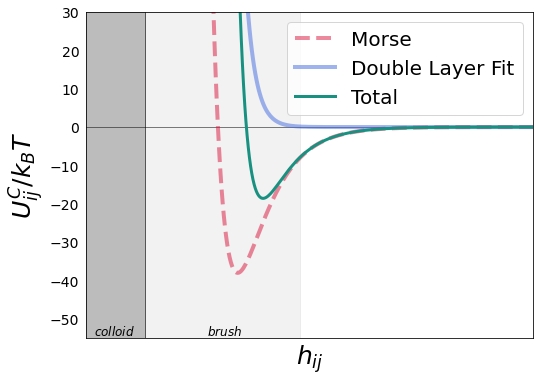

In [4]:
# use this filename to save PNG if "save_bool" == True
plot_title = 'potential_plot'

# select a subset to plot
brush_type = ['H']      # choose: ['H', 'L']
salt =[10]              # choose: [2.5, 3.5, 5, 10]
depletant_values = [8]  # choose: [0.5, 1, 2, 3, 4, 6, 8]

# choose which electrostatic repulsion to plot
plot_list = ['distributed', 'fit']
distributed = False
fit = True
plot_bools = [distributed, fit]

# use "morse_bool", "electro_bool", and "total_bool" to choose 
# whether to show Morse, Electrostatics, or Total potential curves
potential_plot(brush_type, salt, depletant_values, plot_list, plot_title, 
               plot_bools, morse_bool=True, electro_bool=True, total_bool=True, save_bool=False)